# PHẦN 2: THỰC NGHIỆM, SO SÁNH VÀ THẢO LUẬN TRÊN DỮ LIỆU THỰC TẾ
**Môn học:** Toán Ứng Dụng và Thống Kê (MTH00051)

Notebook này thực hiện bài toán dự báo giá xe ô tô dựa trên tập dữ liệu thực tế `automobile.csv`. Chúng ta sẽ kết hợp quy trình tiền xử lý tự động qua `DataPipeline` và tiến hành thử nghiệm, đánh giá so sánh hiệu năng của nhiều mô hình hồi quy khác nhau từ cơ bản đến nâng cao.

### Các mô hình tham gia so sánh:
1. **OLS:** Hồi quy bình phương tối thiểu sử dụng toàn bộ đặc trưng.
2. **OLS:** OLS kết hợp lựa chọn đặc trưng (Backward Elimination theo $p$-value hoặc VIF).
3. **Ridge Regression:** Hồi quy Ridge với siêu tham số $\lambda$ tối ưu bằng $K$-Fold Cross Validation.
4. **Lasso Regression:** Hồi quy Lasso với siêu tham số $\lambda$ tối ưu bằng $K$-Fold Cross Validation.
5. **Kernel Ridge Regression (RBF Kernel):** Hồi quy phi tuyến trong không gian đặc trưng dual, tối ưu cả $\lambda$ và $\ell$.
6. **Bayesian Linear Regression:** Hồi quy Bayes định lượng độ bất định.

In [1]:
import sys
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from data_pipeline import DataPipeline
from model_comparison import compare_models, plot_coefficient_importance, to_design_matrix, compare_models_on_automobile
from advanced_methods import (
    compare_advanced_models, 
    kernel_ridge_fit, 
    bayesian_lr_fit, 
    _estimate_sigma2_ols,
    plot_kernel_actual_vs_predicted, 
    plot_bayesian_credible_intervals, 
    plot_kernel_cv_surface
)

## 1. Tải dữ liệu và Xử lý sơ bộ
Tập dữ liệu `automobile.csv` chứa một số ký tự `?` đại diện cho các giá trị bị khuyết thiếu và một số cột số bị nhận nhầm thành kiểu dữ liệu `object`. Ta cần thay thế `?` bằng `NaN` và ép kiểu về dạng số chính xác trước khi đưa vào `DataPipeline`.

In [2]:
# Tải tập dữ liệu thực tế
df_raw = pd.read_csv('data/automobile.csv')

# Thay thế ký tự '?' bằng NaN
df_cleaned = df_raw.replace('?', np.nan)

numeric_cols = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm', 'price']
for col in numeric_cols:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

# Loại bỏ các dòng bị khuyết biến mục tiêu
df_cleaned = df_cleaned.dropna(subset=['price']).reset_index(drop=True)

print(f"Kích thước tập dữ liệu sau khi làm sạch sơ bộ: {df_cleaned.shape}")
print("\nThông tin tổng quan về các cột dữ liệu:")
print(df_cleaned.info())

Kích thước tập dữ liệu sau khi làm sạch sơ bộ: (201, 26)

Thông tin tổng quan về các cột dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               201 non-null    object 
 3   fuel-type          201 non-null    object 
 4   aspiration         201 non-null    object 
 5   num-of-doors       199 non-null    object 
 6   body-style         201 non-null    object 
 7   drive-wheels       201 non-null    object 
 8   engine-location    201 non-null    object 
 9   wheel-base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb-weight        201 non-null    int64  
 14  engine-type        201 n

## 2. Phân tách dữ liệu và thực thi quy trình Data Pipeline
Ta chia dữ liệu thành tập huấn luyện và tập kiểm tra (Test Set) theo tỷ lệ $80:20$. 
Sau đó, ta khởi tạo đối tượng `DataPipeline` để thực hiện tuần tự:
1. Tự động nhận diện và phân loại biến số và biến phân loại.
2. Điền khuyết thiếu (`mean` cho biến số, `mode` cho biến phân loại).
3. Mã hóa One-Hot Encoding cho biến phân loại (sử dụng `drop_first=True` để tránh đa cộng tuyến hoàn hảo).
4. Chuẩn hóa Z-score cho biến số dựa trên các tham số học từ tập Train.

In [3]:
# Phân tách biến dự báo (X) và biến mục tiêu (y)
X = df_cleaned.drop(columns=['price'])
y = df_cleaned['price']

# Chia tập Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Khởi tạo và huấn luyện Pipeline trên tập Train
pipeline = DataPipeline(impute_num='mean', impute_cat='mode')

X_train_scaled = pipeline.fit_transform(X_train)
X_test_scaled = pipeline.transform(X_test)

print(f"Kích thước tập Train sau mã hóa pipeline: {X_train_scaled.shape}")
print(f"Kích thước tập Test sau mã hóa pipeline: {X_test_scaled.shape}")
print("\nMột số cột dữ liệu đầu tiên sau xử lý:")
print(X_train_scaled.iloc[:3, :5])

Kích thước tập Train sau mã hóa pipeline: (160, 64)
Kích thước tập Test sau mã hóa pipeline: (41, 64)

Một số cột dữ liệu đầu tiên sau xử lý:
     symboling  normalized-losses  wheel-base    length     width
198  -1.430369          -0.735258    1.748399  1.227681  1.538623
38   -0.613015          -1.014309   -0.381759  0.114298 -0.297798
24    0.204338           0.743714   -0.855128 -1.389599 -0.992660


## 3. Huấn luyện và so sánh các mô hình cơ bản
Sử dụng hàm `compare_models` trong `model_comparison.py` để lấy bảng kết quả đánh giá các mô hình: OLS toàn phần, OLS lựa chọn biến (Backward Elimination theo $p$-value), Ridge và Lasso trên tập Test thông qua các chỉ số $\text{MAE}$, $\text{RMSE}$, và $R^2$.

In [4]:
# Gọi trực tiếp hàm tích hợp hệ thống, thiết lập k_folds=3 để tối ưu hóa tốc độ xử lý
print("--- Đang huấn luyện, chọn đặc trưng và quét siêu tham số CV cho các mô hình chuẩn ---")
df_standard_results = compare_models_on_automobile(
    data_path="data/automobile.csv",
    test_size=0.2,
    seed=42,
    selection_method="pvalue",   # Chọn biến theo t-test p-value
    alpha=0.05,
    k_folds=3                    # k=3 tối ưu hóa chu trình tính toán thô
)

print("\nKết quả các mô hình tiêu chuẩn trên Test Set:")
display(df_standard_results)

--- Đang huấn luyện, chọn đặc trưng và quét siêu tham số CV cho các mô hình chuẩn ---

Kết quả các mô hình tiêu chuẩn trên Test Set:


,Model,MAE,RMSE,R2,n_features,feature_indices,selected_indices,lambda,cv_mse
0,OLS (Full),30202.508562,58158.636023,-45.402029,122,"[6, 5, 3, 9, 8, 2, 95, 87, 66, 86, 1, 98, 101,...",NaN,NaN,NaN
1,"OLS (Selected, p≤0.05)",2343.913035,4273.684482,0.749439,19,NaN,"[5, 3, 87, 101, 92, 133, 90, 96, 192, 88, 34, ...",NaN,NaN
2,Ridge (CV λ),1958.933953,3795.790068,0.802343,40,"[6, 5, 3, 9, 8, 2, 95, 87, 66, 86, 1, 98, 101,...",NaN,10.0,5.254988e+06
3,Lasso (CV λ),2059.036710,3639.163535,0.818318,40,"[6, 5, 3, 9, 8, 2, 95, 87, 66, 86, 1, 98, 101,...",NaN,100.0,1.284628e+07


## 4. Thử nghiệm các phương pháp nâng cao (Bonus)
Tiếp tục huấn luyện và đánh giá hai mô hình nâng cao được cài đặt hoàn toàn từ đầu:
1. **Kernel Ridge Regression:** Quét lưới siêu tham số để tìm hệ số phạt $\lambda$ và độ rộng không gian $\ell$ tối ưu qua Cross Validation.
2. **Bayesian Linear Regression:** Áp dụng phân phối conjugate posterior với prior Gaussian không mang thông tin ($\tau^2 = 100$) để tính điểm ước lượng.

In [5]:
from model_comparison import load_automobile_splits
from part2.data_pipeline import DataPipeline

# 1. Tách dữ liệu đồng bộ cấu trúc với hàm so sánh chuẩn
X_train_raw, y_train_raw, X_test_raw, y_test_raw = load_automobile_splits(
    data_path="data/automobile.csv", test_size=0.2, seed=42
)

# 2. Xử lý chuẩn hóa qua DataPipeline
pipeline = DataPipeline()
X_tr_scaled = pipeline.fit_transform(X_train_raw)
X_te_scaled = pipeline.transform(X_test_raw)

# 3. Chạy đánh giá các mô hình nâng cao từ advanced_methods.py
print("--- Đang huấn luyện các mô hình nâng cao (Kernel Ridge & Bayesian LR) ---")
df_advanced_results = compare_advanced_models(
    X_train=X_tr_scaled,
    y_train=y_train_raw,
    X_test=X_te_scaled,
    y_test=y_test_raw,
    kr_kernel="rbf",
    kr_lambdas=[0.1, 1.0, 10.0],
    kr_ells=[0.5, 1.0, 2.0],
    k_folds=3,
    seed=42,
    tau2=100.0
)

# 4. Hợp nhất bảng tổng kết toàn diện của đồ án
df_final_comparison = pd.concat([df_standard_results, df_advanced_results], ignore_index=True)

print("\n" + "="*75)
print("   BẢNG TỔNG HỢP SO SÁNH HIỆU NĂNG TOÀN DIỆN CÁC MÔ HÌNH TRÊN TEST SET")
print("="*75)
display(df_final_comparison[["Model", "MAE", "RMSE", "R2", "n_features"]])
print("="*75)

--- Đang huấn luyện các mô hình nâng cao (Kernel Ridge & Bayesian LR) ---

   BẢNG TỔNG HỢP SO SÁNH HIỆU NĂNG TOÀN DIỆN CÁC MÔ HÌNH TRÊN TEST SET


,Model,MAE,RMSE,R2,n_features
0,OLS (Full),30202.508562,58158.636023,-45.402029,122
1,"OLS (Selected, p≤0.05)",2343.913035,4273.684482,0.749439,19
2,Ridge (CV λ),1958.933953,3795.790068,0.802343,40
3,Lasso (CV λ),2059.036710,3639.163535,0.818318,40
4,"Kernel Ridge (RBF, CV λ/ℓ)",3332.975159,5914.718228,0.520071,250
5,Bayesian LR (conjugate),13473.983975,15946.820010,-2.488645,251


## 5. Trực quan hóa và phân tích chuyên sâu
Để có cái nhìn sâu sắc hơn về các mô hình, chúng ta tiến hành vẽ các đồ thị:
1. **Mức độ quan trọng của đặc trưng:** Dựa trên trọng số hệ số $\beta$ thu được từ mô hình OLS.
2. **Đồ thị Thực tế vs Dự đoán của Kernel Ridge:** Đánh giá độ lệch phân phối so với đường dự báo hoàn hảo $y = \hat{y}$.
3. **Khoảng tin cậy Bayes (95% Credible Intervals):** Trực quan hóa biên độ bất định của dự báo đối với các mẫu thử nghiệm.

1. Đang vẽ biểu đồ phân tích tầm quan trọng của đặc trưng...


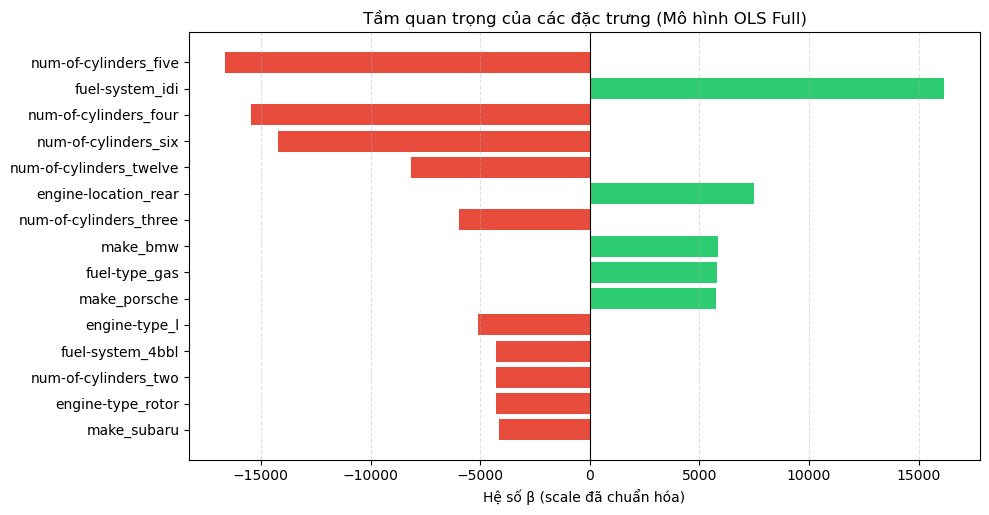


2. Đang vẽ biểu đồ Thực tế vs Dự đoán cho Kernel Ridge Regression...


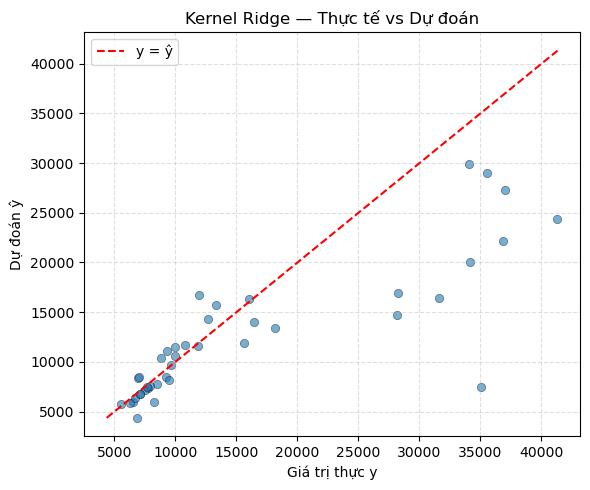


3. Đang vẽ khoảng tin cậy 95% Credible Interval của mô hình Bayesian Linear Regression...


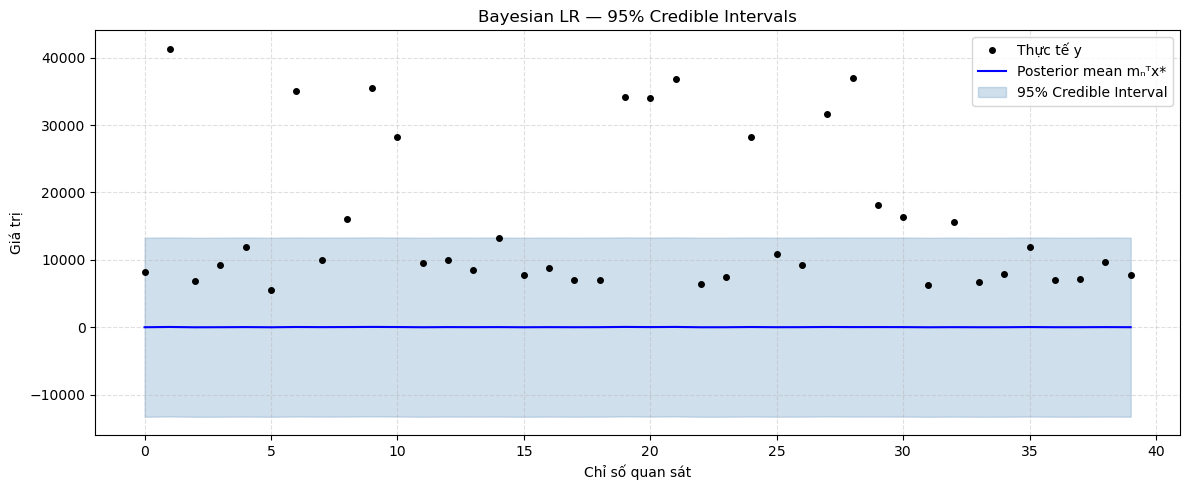

In [6]:
# 1. Trực quan hóa Trọng số Hệ số của mô hình OLS Full
# Lấy hệ số beta từ mô hình OLS Full trên tập dữ liệu design matrix đầy đủ
X_tr_design = to_design_matrix(X_train_scaled)
from part1.ols_implementation import ols_fit
ols_full_fit = ols_fit(X_tr_design, y_train.tolist())

print("1. Đang vẽ biểu đồ phân tích tầm quan trọng của đặc trưng...")
plot_coefficient_importance(
    beta_hat=ols_full_fit["beta_hat"], 
    feature_names=X_train_scaled.columns.tolist(),
    title="Tầm quan trọng của các đặc trưng (Mô hình OLS Full)",
    top_k=15
)

# 2. Trực quan hóa giá trị dự báo thực tế của Kernel Ridge
print("\n2. Đang vẽ biểu đồ Thực tế vs Dự đoán cho Kernel Ridge Regression...")
# Tìm tham số tối ưu bằng cách chạy lại fit tối giản phục vụ đồ thị
X_tr_list = X_train_scaled.values.tolist()
X_te_list = X_test_scaled.values.tolist()
y_tr_list = y_train.tolist()
y_te_list = y_test.tolist()

# Lấy thông số tối ưu từ bảng kết quả đã chạy ở trên
best_lam = df_final_comparison.loc[df_final_comparison['Model'].str.contains('Kernel Ridge'), 'lambda'].values[0]
best_ell = df_final_comparison.loc[df_final_comparison['Model'].str.contains('Kernel Ridge'), 'ell'].values[0]

kr_best_fit = kernel_ridge_fit(X_tr_list, y_tr_list, lam=best_lam, kernel="rbf", ell=best_ell)
plot_kernel_actual_vs_predicted(kr_best_fit, X_te_list, y_te_list)

# 3. Trực quan hóa Khoảng tin cậy Bayes (Uncertainty Quantification)
print("\n3. Đang vẽ khoảng tin cậy 95% Credible Interval của mô hình Bayesian Linear Regression...")
X_tr_design_list = [[1.0] + row for row in X_tr_list]
X_te_design_list = [[1.0] + row for row in X_te_list]
sigma2_hat = _estimate_sigma2_ols(X_tr_design_list, y_tr_list)
bayes_fit_result = bayesian_lr_fit(X_tr_design_list, y_tr_list, sigma2=sigma2_hat, tau2=100.0)

plot_bayesian_credible_intervals(X_te_design_list, y_te_list, bayes_fit_result, n_show=40)